## 1. Import Necessary Libraries

In [51]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## 2. Import Dataset

In [2]:
cars_data = pd.read_csv(filepath_or_buffer = "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding

### 3.1 Initial Data Analysis

In [5]:
cars_data.shape

(81, 5)

In [9]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [17]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [19]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Now Let's check for Assumptions

## Test 1: Linearity Test

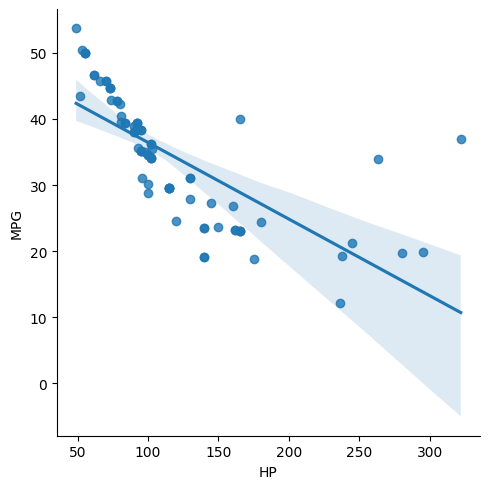

In [21]:
sns.lmplot(data = cars_data, x="HP", y="MPG",)

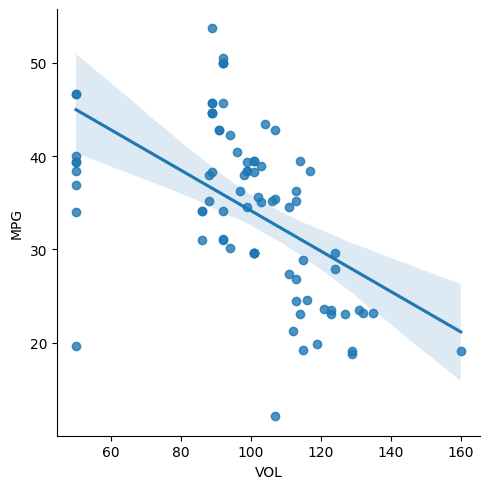

In [23]:
sns.lmplot(data = cars_data, x="VOL", y="MPG")

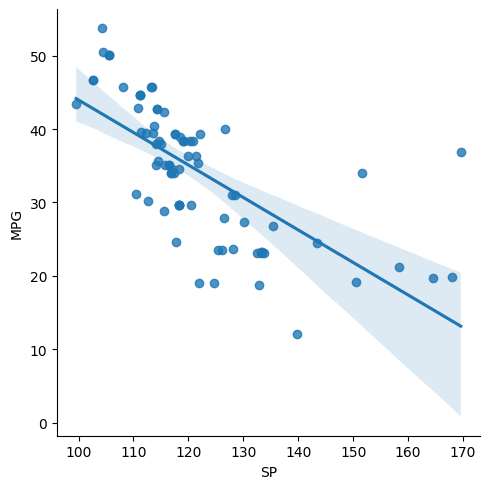

In [25]:
sns.lmplot(data = cars_data, x="SP", y="MPG",)

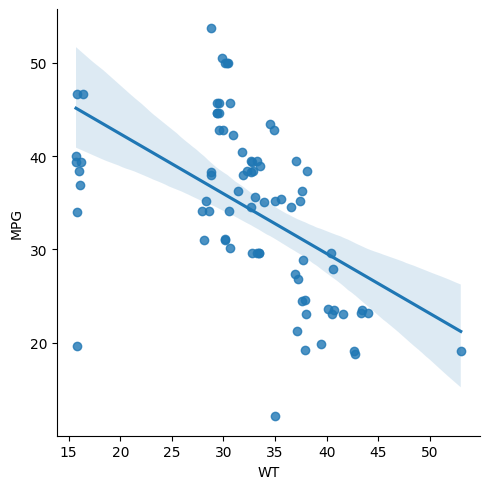

In [27]:
sns.lmplot(data = cars_data, x="WT", y="MPG")

### Test 1 Linearity Failed

## Test 2: Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

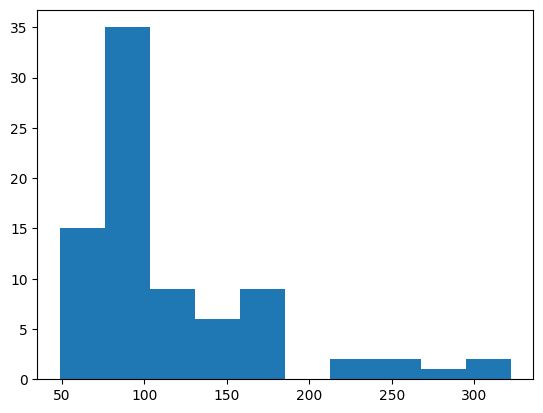

In [29]:
plt.hist(cars_data["HP"])

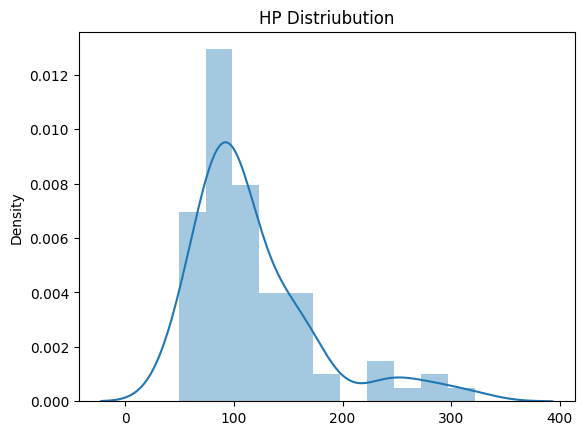

In [31]:
sns.distplot(x=cars_data["HP"])
plt.title("HP Distriubution")
plt.show()

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

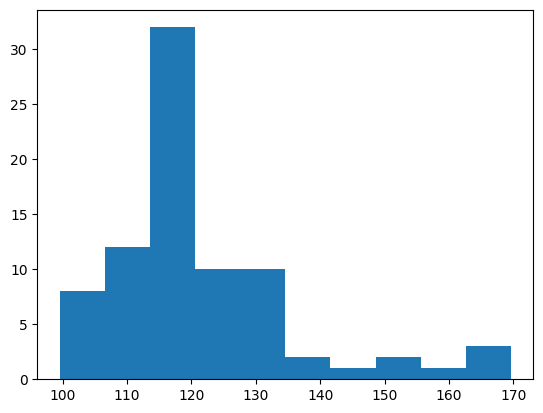

In [33]:
plt.hist(cars_data["SP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

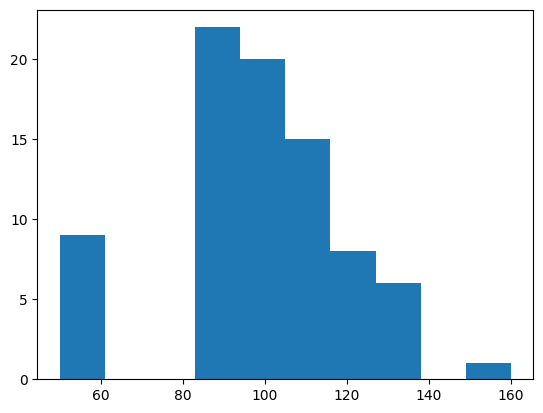

In [35]:
plt.hist(cars_data["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

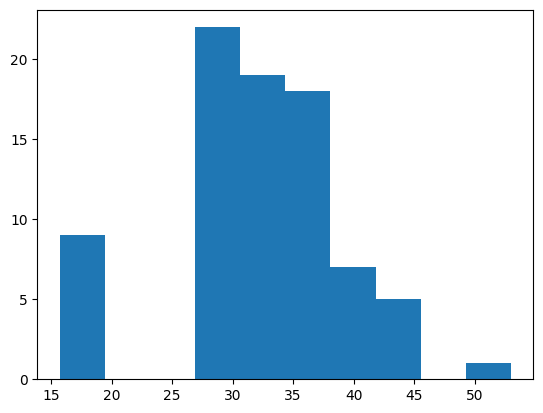

In [37]:
plt.hist(cars_data["WT"])

### Test 2 Normality also failed

## Test 3: MultiCollinearity Test

In [39]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


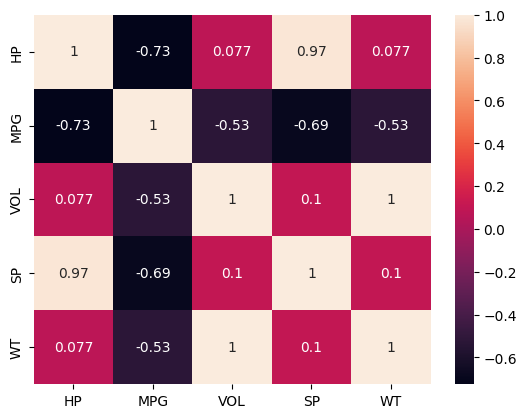

In [41]:
sns.heatmap(data = corr_matrix,annot=True)
plt.show()

### Test 3: There is MultiCollinearity in the Test 

## Test 4: AutoRegression Passed

## 4. Data Preparation

In [42]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [44]:
X = cars_data[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [46]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

### There is Nothing to Prepare because all the datas are numeric

## 5. Model Building

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,shuffle=True, random_state=34)

In [55]:
X_train

,HP,VOL,SP,WT
17,92,50,117.598513,16.194122
52,115,124,120.404312,40.398164
16,78,91,114.369293,29.535784
39,130,92,128.461264,30.115434
22,95,101,120.288996,32.675828
...,...,...,...,...
11,92,50,117.598513,15.753535
69,245,112,158.300669,37.141733
35,90,98,115.013085,31.911223
68,165,123,133.312342,40.472042


In [57]:
X_test

,HP,VOL,SP,WT
59,100,115,115.576579,37.662874
49,115,101,118.288996,33.458472
7,62,50,102.598513,15.847758
27,92,99,119.105055,32.835069
74,140,129,121.864163,42.618698
61,120,116,117.668550,37.860411
64,150,121,128.128401,40.159482
12,92,99,122.105055,32.813592
44,93,102,114.380966,33.078632
30,84,114,113.484609,37.042350


In [59]:
linear_model = LinearRegression()

## 6.Model Training

In [60]:
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7. Model Testing

### Training Data

In [61]:
y_pred_train = linear_model.predict(X_train)
y_pred_train

array([46.75462614, 29.357921  , 40.59531094, 35.55326361, 37.45059013,
       41.68332337, 32.74736225, 38.35204467, 15.7960024 , 40.45702296,
       39.41888236, 37.47703884, 41.42599626, 23.56427857, 41.17403166,
       26.5237502 , 28.78854008, 35.36168615, 34.25957557, 45.49336752,
       28.4717663 , 35.06820535, 37.09928504, 35.15766796, 36.67235696,
       33.15321636, 42.01639762, 27.80720182, 39.307307  , 38.31289001,
       35.40477942, 23.98357674, 20.38133197, 35.57491245, 36.87008928,
       37.67749978, 41.91914635, 38.82344891, 41.18680984, 30.1294102 ,
       26.62411662, 12.83999048, 36.13102051, 37.3420992 , 35.52563974,
       47.2231036 , 34.40109066, 26.95474873, 37.18263291, 37.54744214,
       33.34178579, 22.83470605, 42.72264178, 25.77796412, 38.23393319,
       19.94553155, 21.76768197, 40.92851149, 36.08544444, 46.38165859,
       20.50748319, 37.20180937, 24.76848656, 35.04420344])

### Test Data

In [63]:
y_pred_test = linear_model.predict(X_test)
y_pred_test

array([32.39394585, 33.36020646, 46.7899155 , 38.66601593, 24.47175816,
       28.8901298 , 26.47157047, 39.78131375, 35.4949115 , 34.74024237,
       42.81695793, 41.37820079, 42.31502785, 36.39884247, 25.06481155,
       18.25707928, 42.15044765])

## 8. Model Evaluation

### Training Data Evaluation Metrics

In [91]:
train_error = y_train - y_pred_train
train_error

17   -7.400532
52    0.272015
16    2.194598
39   -4.539133
22    0.860016
        ...   
11   -7.027564
69    0.766225
35    0.756934
68   -1.665315
33    1.241253
Name: MPG, Length: 64, dtype: float64

In [93]:
train_error.mean()

np.float64(1.1934897514720433e-15)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [67]:
mean_absolute_error(y_train, y_pred_train)

3.1298305777220112

In [69]:
mean_squared_error(y_train, y_pred_train)

17.767616779110305

In [72]:
root_mean_squared_error(y_train, y_pred_train)

4.2151650951190875

In [76]:
 r2_score(y_train, y_pred_train)

0.7657768244482415

In [82]:
import statsmodels.formula.api as smf

In [84]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


### To see Adjusted R2 Score , We are using OLS technique from StatsModels Formula

In [117]:
linear_stats_model = smf.ols(formula = "MPG ~ HP", data = cars_data).fit()

In [118]:
print("R2 Score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.5257 
Adjusted R2 Score: 0.5197


In [120]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL", data = cars_data).fit()

In [121]:
print("R2 Score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7507 
Adjusted R2 Score: 0.7443


In [122]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP", data = cars_data).fit()

In [124]:
print("R2 Score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7704 
Adjusted R2 Score: 0.7614


In [133]:
linear_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()

In [129]:
print("R2 Score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7705 
Adjusted R2 Score: 0.7585


### Test Data Evaluation Metrics

In [96]:
test_error = y_test - y_pred_test
test_error

59    -3.533721
49    -3.730271
7     -0.073361
27    -0.255013
74    -5.385418
61    -4.280998
64    -2.866412
12    -0.427220
44     0.148646
30     4.690993
0     10.883723
15     3.274633
3      3.381295
48    -5.384712
78     8.935188
77     0.940808
1      7.862953
Name: MPG, dtype: float64

In [98]:
test_error.mean()

np.float64(0.8341833225308835)

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [102]:
mean_absolute_error(y_test, y_pred_test)

3.8856096980629182

In [104]:
mean_squared_error(y_test, y_pred_test)

24.4931887283102

In [106]:
root_mean_squared_error(y_test, y_pred_test)

4.949059378135425

In [108]:
r2_score(y_test, y_pred_test)

0.7674401633557068

In [110]:
import statsmodels.formula.api as smf

In [111]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
